/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1488
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1765
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1818
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1926
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1114
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1407
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py

Chosen max_len: 85
Dataset shape: (2282, 128, 85, 1)


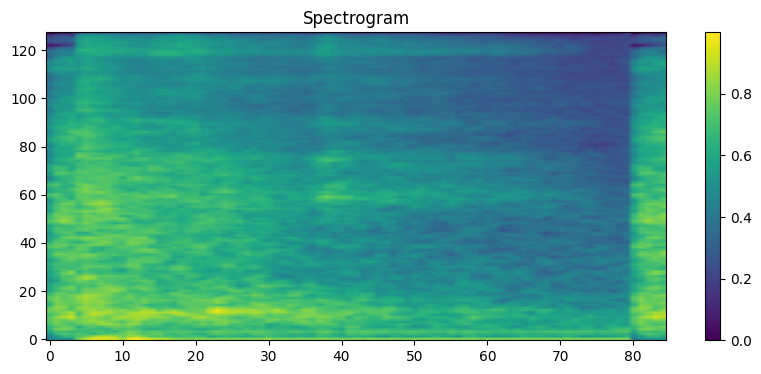

In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt

DATA_PATH = "./dataset"
SILENCE_PATH = "./dataset/silence.flac"

SR = 22050
N_MELS = 128

# 🎧 Extract spectrogram

def extract_spectrogram(file_path):
    y, _ = librosa.load(file_path, sr=SR)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_mels=N_MELS
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db



# Compute max_len (75 percentile)

def compute_max_len(data_path):
    lengths = []

    for file in os.listdir(data_path):
        if file.endswith(".flac") and file != "silence.flac":
            spec = extract_spectrogram(os.path.join(data_path, file))
            lengths.append(spec.shape[1])

    max_len = int(np.percentile(lengths, 75))
    print("Chosen max_len:", max_len)

    return max_len



# Load silence spectrogram
# Since the audio clips are of various length, am using audio of silence for padding

def load_silence_spec(max_len):
    spec = extract_spectrogram(SILENCE_PATH)

    if spec.shape[1] < max_len:
        pad = max_len - spec.shape[1]
        spec = np.pad(
            spec,
            ((0, 0), (0, pad)),
            constant_values=np.min(spec)
        )

    return spec


# Adding slight noise to silence

def get_noisy_silence_slice(silence_spec, width):
    slice_ = silence_spec[:, :width].copy()

    noise = np.random.normal(
        loc=0.0,
        scale=0.01,   # small noise
        size=slice_.shape
    )

    return slice_ + noise



#  Load dataset
def load_dataset(data_path):
    data = []

    max_len = compute_max_len(data_path)
    silence_spec = load_silence_spec(max_len)

    for file in os.listdir(data_path):
        if file.endswith(".flac") and file != "silence.flac":

            path = os.path.join(data_path, file)
            spec = extract_spectrogram(path)

            # Padding
            if spec.shape[1] < max_len:
                pad_width = max_len - spec.shape[1]

                # random split
                pad_left = np.random.randint(0, pad_width + 1)
                pad_right = pad_width - pad_left

                left_pad = get_noisy_silence_slice(silence_spec, pad_left)
                right_pad = get_noisy_silence_slice(silence_spec, pad_right)

                spec = np.concatenate([left_pad, spec, right_pad], axis=1)

            else:
                spec = spec[:, :max_len]

            # per-sample normalization
            spec = (spec - np.min(spec)) / (np.max(spec) - np.min(spec) + 1e-8)

            data.append(spec)

    data = np.array(data)
    data = data[..., np.newaxis]

    return data


# Visualization
def plot_spectrogram(spec):
    plt.figure(figsize=(10, 4))
    plt.imshow(spec, aspect='auto', origin='lower')
    plt.colorbar()
    plt.title("Spectrogram")
    plt.show()


X = load_dataset(DATA_PATH)

print("Dataset shape:", X.shape)

# visualize sample
plot_spectrogram(X[0].squeeze())

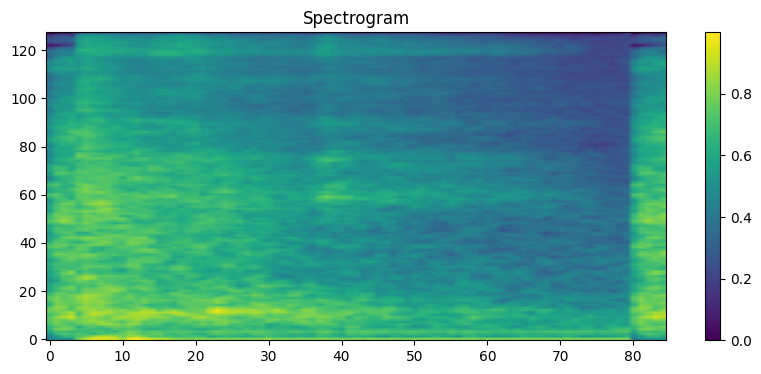

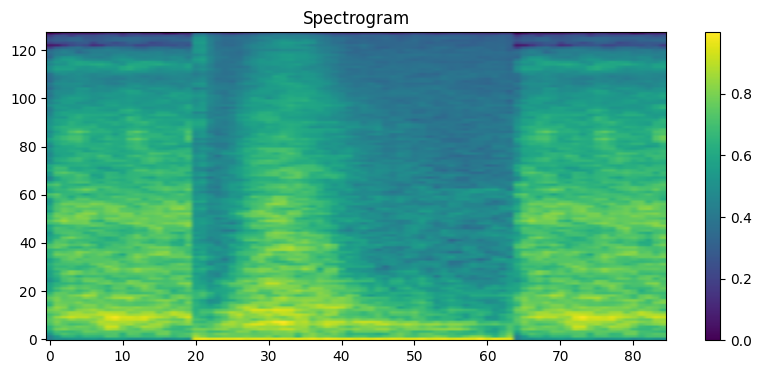

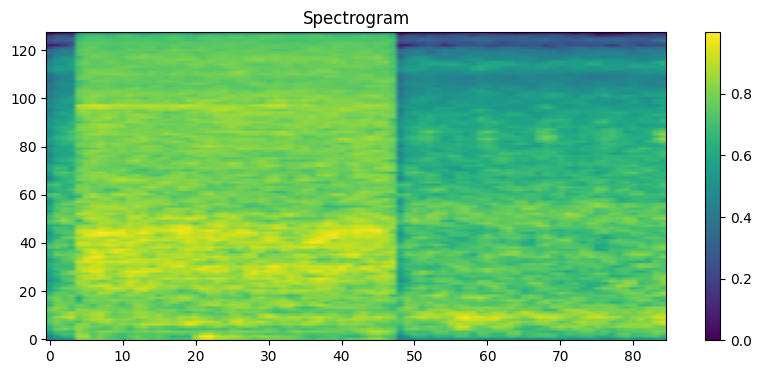

In [ ]:
plot_spectrogram(X[0].squeeze())
plot_spectrogram(X[1].squeeze())
plot_spectrogram(X[2].squeeze())

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras import layers, models

input_shape = (128, 85, 1)

inputs = layers.Input(shape=input_shape)

# ---------------- ENCODER ----------------
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)

# ---------------- DECODER ----------------
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# FIX: crop width to 85
x = layers.Cropping2D(cropping=((0, 0), (0, 3)))(x)
# 88 → 85 (removes 3 columns from right)

# ---------------- MODEL ----------------
autoencoder = models.Model(inputs, x)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 85, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 85, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 43, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 22, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 11, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 22, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 64, 44, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 44, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 128, 88, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 88, 1)     │           289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 128, 85, 1)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X, X,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - loss: 0.0029 - val_loss: 0.0028
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - loss: 0.0028 - val_loss: 0.0028
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - loss: 0.0026 - val_loss: 0.0025
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - loss: 0.0024 - val_loss: 0.0024
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - loss: 0.0023 - val_loss: 0.0024
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - loss: 0.0022 - val_loss: 0.0023
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - loss: 0.0022 - val_loss: 0.0021
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - loss: 0.0021 - val_loss: 0.0021
Epoch 9/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - loss: 0.0020 - val_loss: 0.0020
Epoch 10/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - loss: 0.0020 - val_loss: 0.0020


In [ ]:
autoencoder.save("autoencoder.h5")